# Assignment 8: Explainable Machine Learing (Part 1)

## Objective:

Interpreting how a machine learning model works is crucial from many aspects, such as debugging the model, improving the model, and derive new insights from the model. There are many model explanation techniques that we can use for interpreting a black box model itself or its predictions. Also, some models are transparent that we can directly get insights from its structure or learned parameters. In this assignment, you are going to train different models on a dataset and try different approaches to explain the model and get some insights. After completing this assignment, you should be able to answer the following questions:

1. How to explain transparent models?
2. How to implement the permutation method to explain black-box models?
3. How to create and interpret partial dependence plots?
4. How to implement the global surrogate method to explain black-box models?
5. How to use SHAP to explain model predictions and interpret its explanation results? 
6. How to use LIME to explain model predictions and  interpret its explanation results? 

The data can be downloaded from [A8-1-data.zip](A8-1-data.zip)



## 0. Preparation

Import relevant libraries and load the dataset:

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import log_loss
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

The dataset we are going to use is a binary forest covertype dataset and we will predict the forest cover type from cartographic variables only. The first ten features are numerical features, there are also two categorical features in a one-hot encoding fashion (4 and 40 vector length each), the last column is the target forest cover type (binary). More details about the dataset can be found at [https://archive.ics.uci.edu/ml/datasets/covertype](https://archive.ics.uci.edu/ml/datasets/covertype). Please make sure you understand the meaning of each feature.

In [2]:
# load data and take a look at data distribution
data = pd.read_csv('bforest_sample.csv', delimiter=',')

In [3]:
# split data into training and test dataset with respect to ratio 0.8:0.2
train, test = train_test_split(data, test_size=0.2, random_state=733)
X_train, y_train = train.iloc[:, :-1], train.iloc[:, -1]
X_test, y_test = test.iloc[:, :-1], test.iloc[:, -1]
feature_names = list(X_train)

# rescale
scaler = MinMaxScaler()
X_train = pd.DataFrame(data=scaler.fit_transform(X_train), columns=feature_names)
X_test = pd.DataFrame(data=scaler.transform(X_test), columns=feature_names)


## Task 1. Transparent Model

In this task, you are going to train a logistic regression model and interpret it. For logistic regression, since the effect of each feature is simply added together, we can interpret it directly by looking at the coefficient of each feature. Please follow the comment to finish the code:

In [4]:
# train a logistic regression model
lr = LogisticRegression(solver='liblinear').fit(X_train, y_train)

In [5]:
# set default figure size
plt.rcParams['figure.figsize'] = [16, 8]

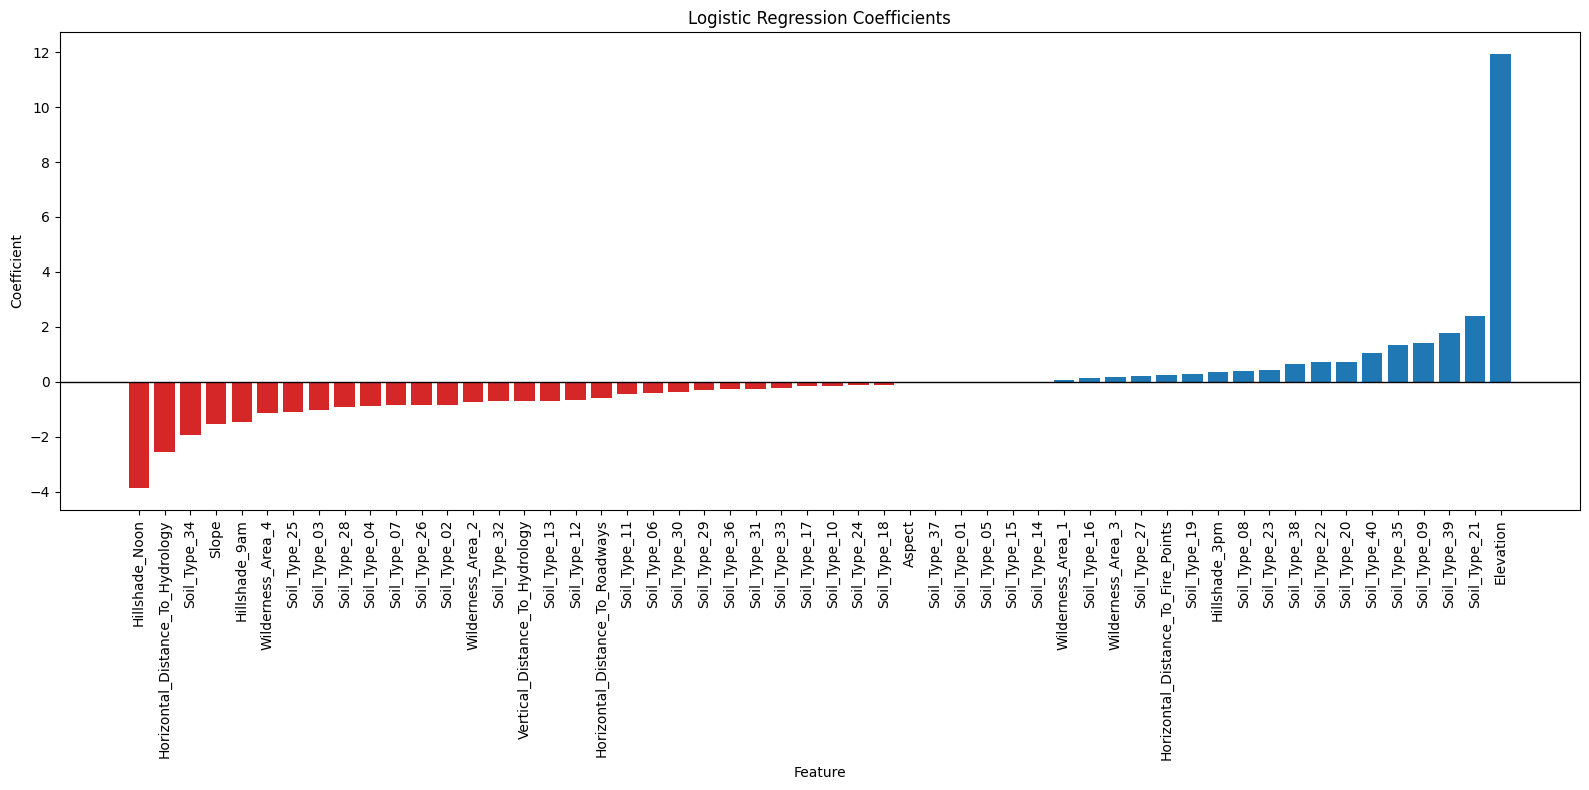

In [7]:
# show the coefficient value for each feature by a bar chart
def explain_logistic_regression(lr, feature_names):
    coefs = pd.Series(lr.coef_[0], index=feature_names).sort_values()
    colors = ['tab:red' if value < 0 else 'tab:blue' for value in coefs]

    plt.bar(coefs.index, coefs.values, color=colors)
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    plt.xlabel('Feature')
    plt.ylabel('Coefficient')
    plt.title('Logistic Regression Coefficients')
    plt.tight_layout()
    plt.show()

# explain the model
explain_logistic_regression(lr, feature_names)

For a specific prediction, we can get a more concrete effect of each feature by the product of the coefficient and input feature value. Please follow the comment to finish the code:

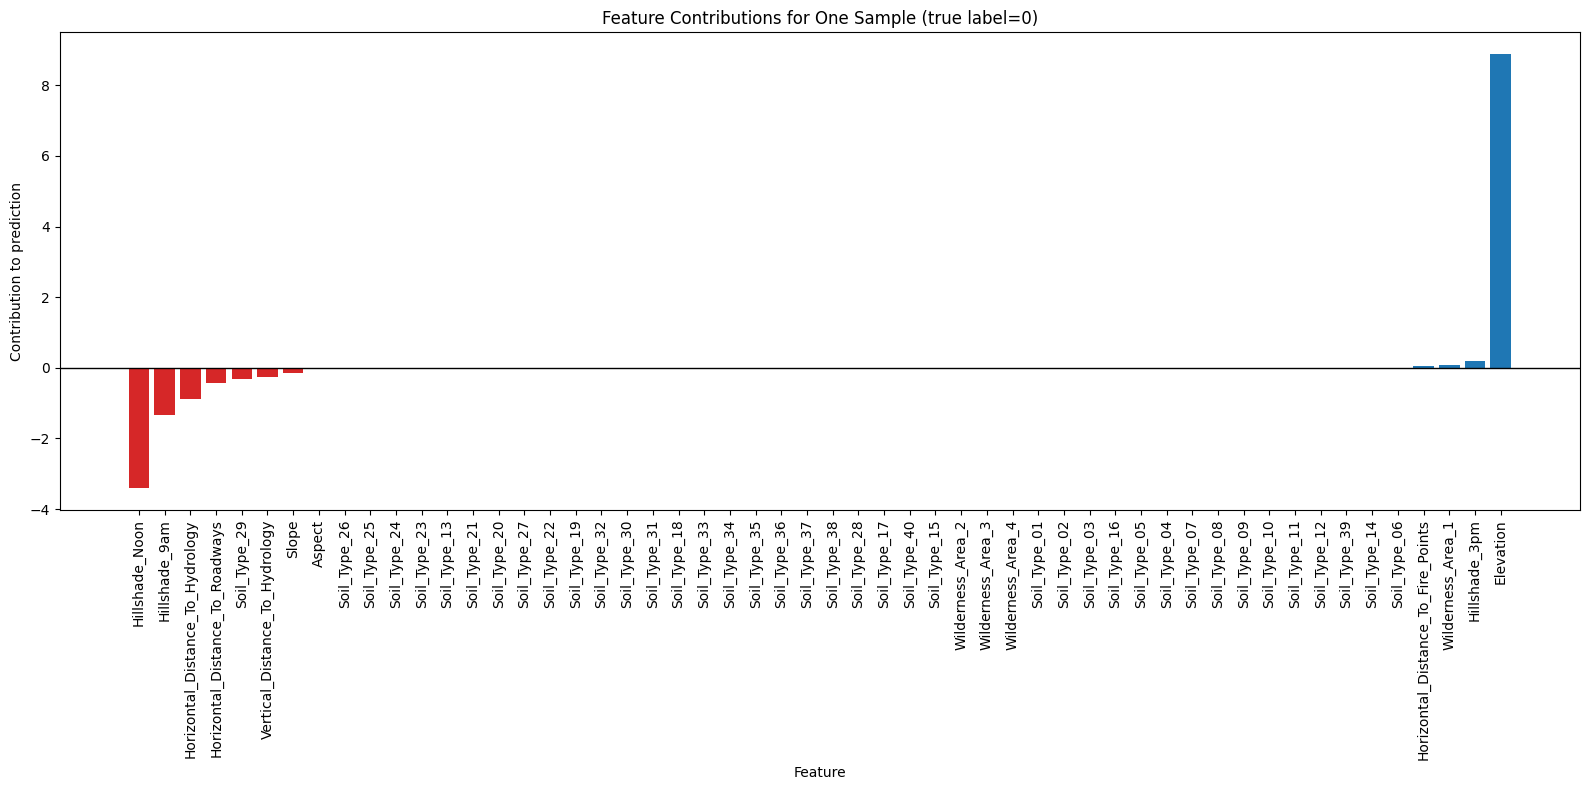

In [8]:
# show the effect from each input feature by a bar chart
def explain_logistic_regression_prediction(lr, feature_names, sample):
    x, y = sample
    effects = pd.Series(lr.coef_[0] * x.to_numpy(), index=feature_names).sort_values()
    colors = ['tab:red' if value < 0 else 'tab:blue' for value in effects]

    plt.bar(effects.index, effects.values, color=colors)
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    plt.xlabel('Feature')
    plt.ylabel('Contribution to prediction')
    plt.title(f'Feature Contributions for One Sample (true label={y})')
    plt.tight_layout()
    plt.show()
    
explain_logistic_regression_prediction(lr, feature_names, (X_test.iloc[0, :], y_test.iloc[0]))

What can you get from the above plots? Please write down two findings:

**Findings:**
1. In both plots, Elevation is the most important positive feature. It has the largest positive coefficient in the first plot, and it also gives the largest positive contribution in the second plot. This means Elevation is important in the model overall and also important for this sample.
2. Hillshade_Noon is one of the strongest negative features in both plots. In the first plot, it has the largest negative coefficient, and in the second plot, it gives the largest negative contribution for this sample. This shows that Hillshade_Noon strongly pushes the prediction toward class 0 for this sample.

## Task 2. Post-hoc Explanation (Global Model)

In this task, you are going to build a gradient boosting tree model and a neural network, and use some techniques we introduced in class to interpret these models. First, let's train the models using training data:

In [9]:
# train a gradient boosting classifier
gb = GradientBoostingClassifier().fit(X_train, y_train)

In [ ]:
# train a multi-layer perceptron classifier
# reduce max_iter to 20 because training takes too long on my laptop
mlp = MLPClassifier(learning_rate_init=0.1, verbose=True, max_iter=20).fit(X_train, y_train)

Iteration 1, loss = 0.53162283
Iteration 2, loss = 0.48855044
Iteration 3, loss = 0.47255054
Iteration 4, loss = 0.47058873
Iteration 5, loss = 0.47093529
Iteration 6, loss = 0.46734391
Iteration 7, loss = 0.46512545
Iteration 8, loss = 0.46069277
Iteration 9, loss = 0.45734039
Iteration 10, loss = 0.45456456
Iteration 11, loss = 0.45733566
Iteration 12, loss = 0.45404865
Iteration 13, loss = 0.45361575
Iteration 14, loss = 0.45241838
Iteration 15, loss = 0.44672516
Iteration 16, loss = 0.44575030
Iteration 17, loss = 0.44477759
Iteration 18, loss = 0.44683803
Iteration 19, loss = 0.44552264
Iteration 20, loss = 0.44530864


/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


### 2.1 Permutation

/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: 

Elevation                             0.385355
Horizontal_Distance_To_Roadways       0.034819
Horizontal_Distance_To_Hydrology      0.023901
Hillshade_Noon                        0.019735
Horizontal_Distance_To_Fire_Points    0.015410
dtype: float64


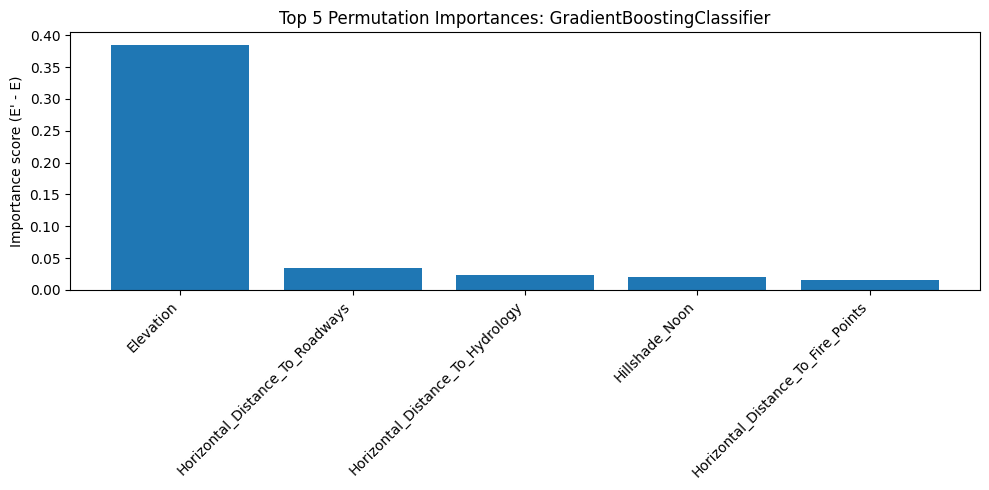

/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifi

Elevation                           0.560106
Horizontal_Distance_To_Roadways     0.101804
Wilderness_Area_3                   0.069733
Horizontal_Distance_To_Hydrology    0.067466
Hillshade_Noon                      0.044783
dtype: float64


/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


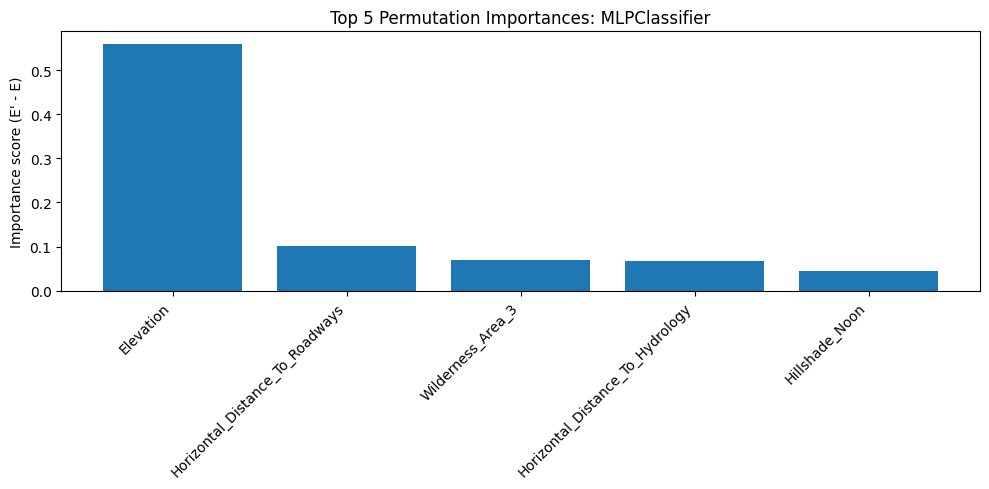

In [13]:
# get importance score (E' - E) for each feature by permutation, use log_loss as error
def permutation_importance(model, feature_names, X, y):
    ''' calculate importance score for each feature by purmutation approach '''

    # use a fixed random seed so the result is repeatable
    rng = np.random.RandomState(733)
    # E: error on the original data
    base_error = log_loss(y, model.predict_proba(X))
    importance_scores = []

    # shuffle one feature at a time and measure how much error increases
    for i, feature in enumerate(feature_names):
        X_permuted = X.copy()
        X_permuted[:, i] = rng.permutation(X_permuted[:, i])
        permuted_error = log_loss(y, model.predict_proba(X_permuted))
        # importance = E' - E
        importance_scores.append(permuted_error - base_error)

    # sort features from most important to least important
    importance = pd.Series(importance_scores, index=feature_names).sort_values(ascending=False)
        
    ''' show the top 5 most important features '''
    top5 = importance.head(5)
    print(top5)
    plt.figure(figsize=(10, 5))
    plt.bar(top5.index, top5.values)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Importance score (E' - E)")
    plt.title(f"Top 5 Permutation Importances: {model.__class__.__name__}")
    plt.tight_layout()
    plt.show()
    
permutation_importance(gb, feature_names, X_test.to_numpy(), y_test.to_numpy())
permutation_importance(mlp, feature_names, X_test.to_numpy(), y_test.to_numpy())

### 2.2 Partial dependence plots

In this section, you are going to use the [plot_partial_dependence](https://scikit-learn.org/stable/auto_examples/inspection/plot_partial_dependence.html) provided by sklearn to see the marginal effect of each single numerical features:

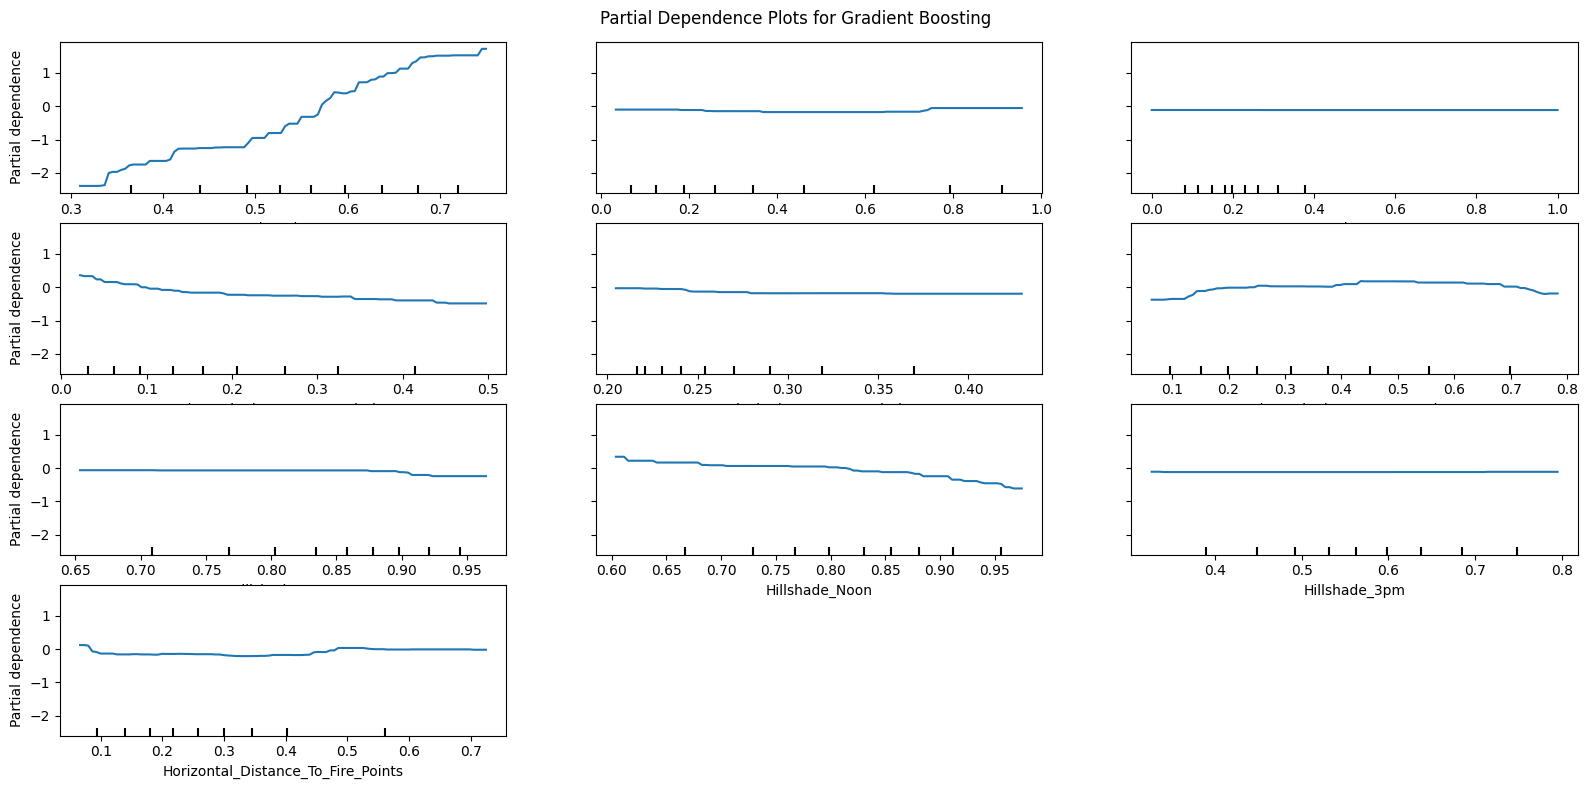

In [14]:
# plot partial dependence for numerical features (first 10 features) for gradient boosting classifier
PartialDependenceDisplay.from_estimator(
    gb,
    X_train,
    features=range(10),
    feature_names=feature_names
)
plt.suptitle('Partial Dependence Plots for Gradient Boosting')
plt.tight_layout()
plt.show()

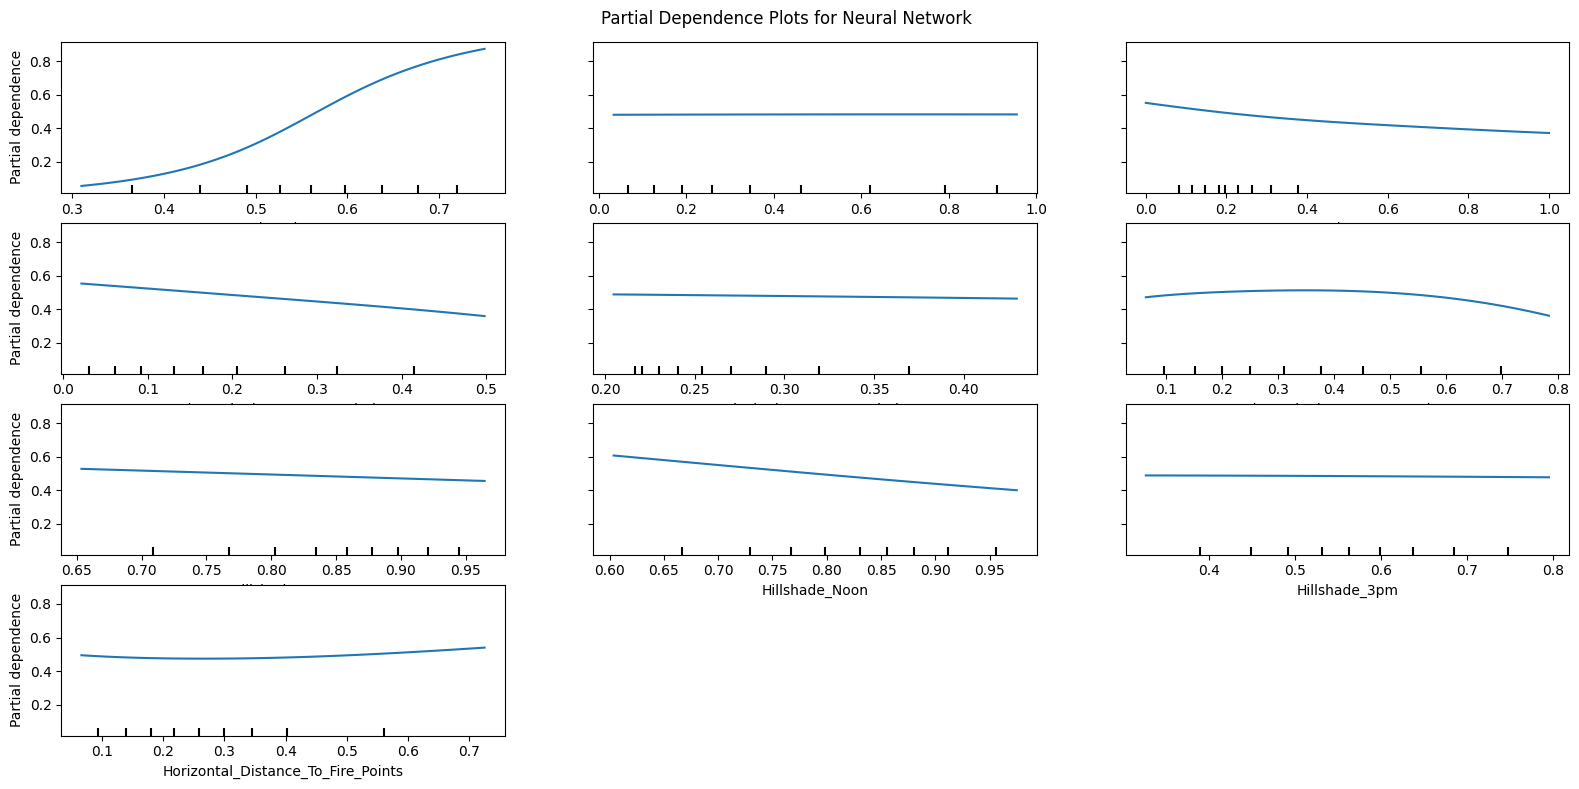

In [15]:
# plot partial dependence for numerical features (first 10 features) for neural network
PartialDependenceDisplay.from_estimator(
    mlp,
    X_train,
    features=range(10),
    feature_names=feature_names
)
plt.suptitle('Partial Dependence Plots for Neural Network')
plt.tight_layout()
plt.show()

### 2.3 Global Surrogate

Now, let's train a simple logistic regression based on the gradient boosting tree model and neural network we built before. And use the method we implemented previously to interpret the derived transparent model:

Global surrogate for Gradient Boosting


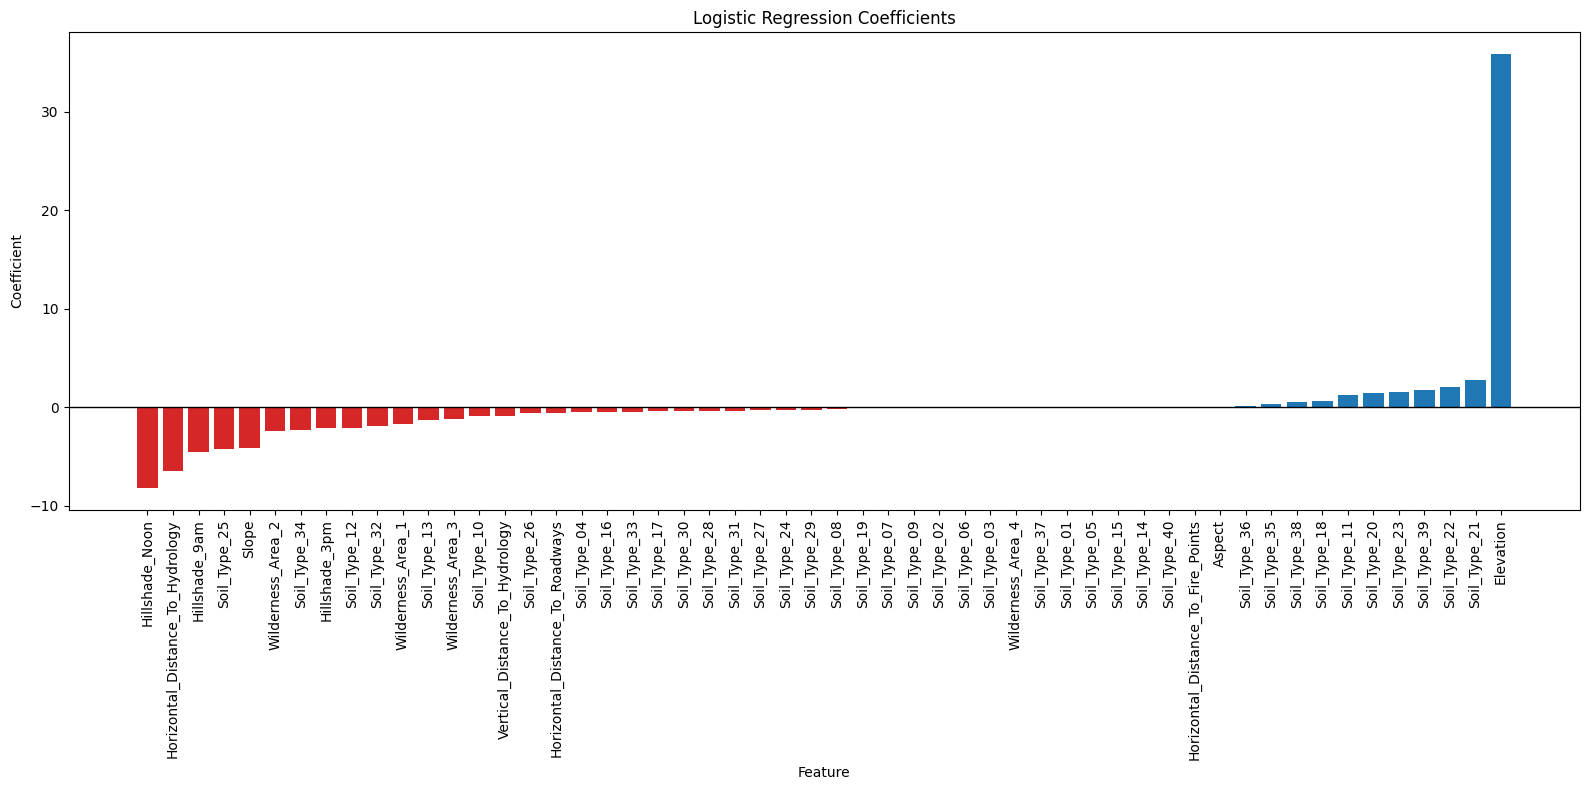

Global surrogate for Neural Network


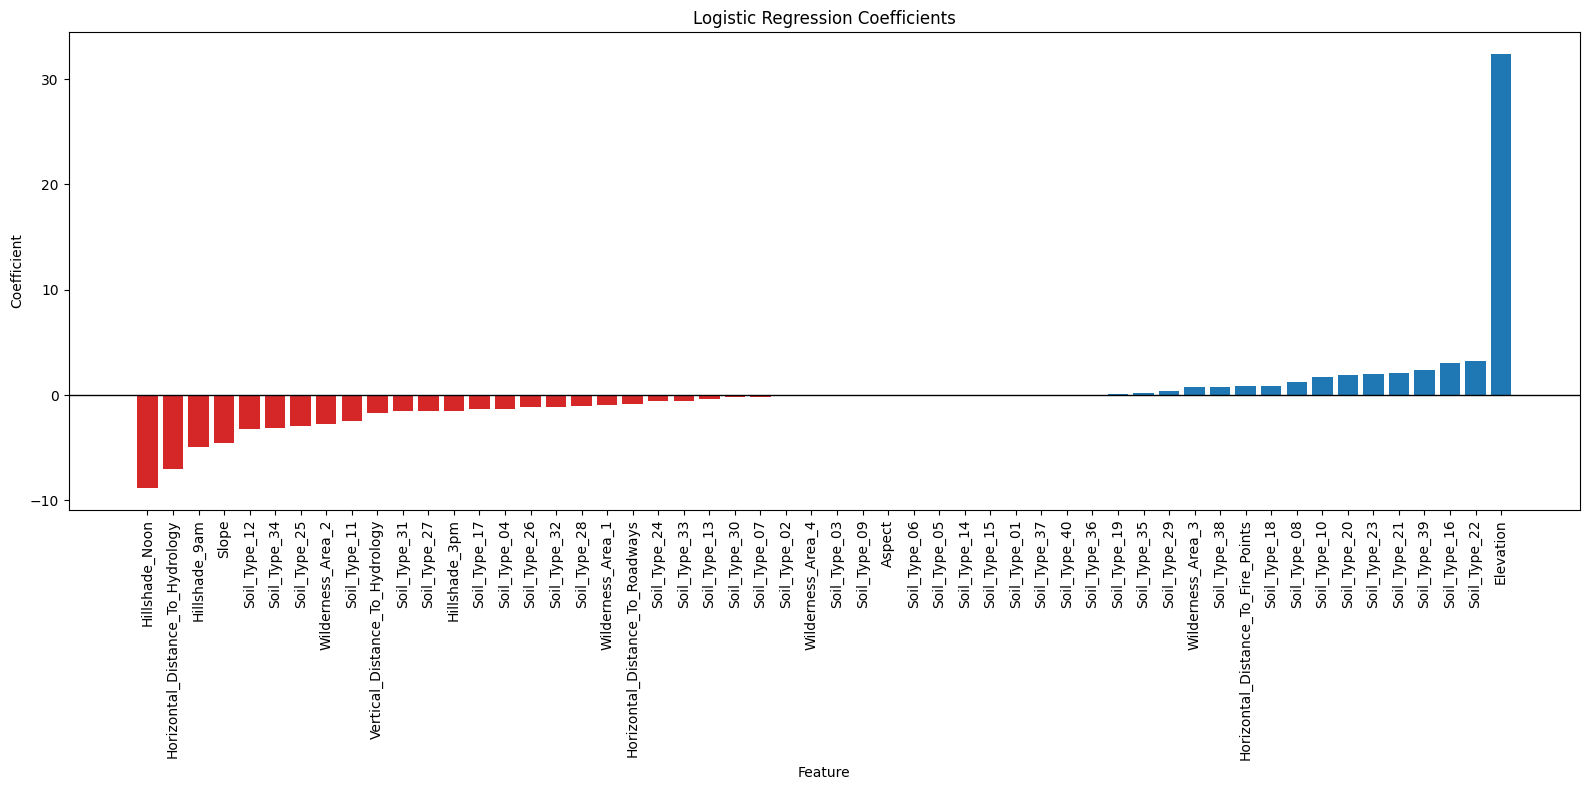

In [16]:
# train a logistic regression model on gb and mlp and explain using explain_logistic_regression()

# use the predictions of gb as labels for a simple surrogate model
gb_surrogate_y = gb.predict(X_train)
gb_surrogate = LogisticRegression(solver='liblinear').fit(X_train, gb_surrogate_y)
print('Global surrogate for Gradient Boosting')
explain_logistic_regression(gb_surrogate, feature_names)

# use the predictions of mlp as labels for another surrogate model
mlp_surrogate_y = mlp.predict(X_train)
mlp_surrogate = LogisticRegression(solver='liblinear').fit(X_train, mlp_surrogate_y)
print('Global surrogate for Neural Network')
explain_logistic_regression(mlp_surrogate, feature_names)

## Task 3. Post-hoc Explanation (Single Prediction)

### 3.1 Attribution

From now, let's focus on interpreting single predictions. [SHAP](https://github.com/shap/shap) is an efficient method to approximatly calculate the shapely value we mentioned in class. Please install the library and take a look at the doc. Explain the first prediction made by the gradient boosting tree model in the test set:

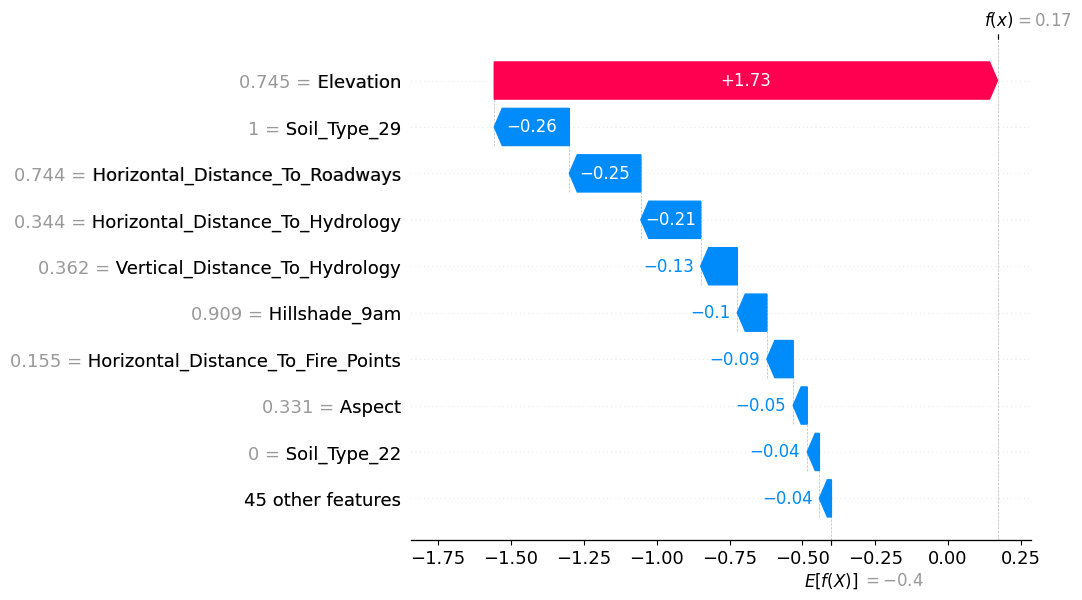

In [19]:
import shap

# load JS visualization code to notebook
shap.initjs()

# use Tree SHAP explainer to explain the gradient boosting tree model
# you only need to explain and plot the first explaination
# build a Tree SHAP explainer for the gradient boosting model
explainer = shap.TreeExplainer(gb)

# explain only the first test sample
shap_values = explainer(X_test.iloc[[0]])

# show the SHAP values for the first prediction
shap.plots.waterfall(shap_values[0])

What can you get from the above representation? Please write down two findings:

**Findings:**
1. Elevation has the largest positive SHAP value, about +1.73, so it is the main reason why the prediction goes up. This means Elevation = 0.745 strongly pushes the model toward the final prediction f(x) = 0.17.
2. Several features push the prediction down, including Soil_Type_29 (-0.26), Horizontal_Distance_To_Roadways (-0.25), Horizontal_Distance_To_Hydrology (-0.21), and Vertical_Distance_To_Hydrology (-0.13). However, these negative effects are smaller than the positive effect of Elevation, so the final prediction stays above the baseline E[f(X)] = -0.4.

### 3.2 LIME

[LIME](https://github.com/marcotcr/lime) is a library implemented by the authors of the paper. Please install the library and take a look at the doc and tutorial. Use it to explain the first prediction made by the neural network model in the test set:

In [28]:
import lime.lime_tabular

# use LimeTabularExplainer to explain the neural network model
# you only need to explain and plot the first explaination
# build a LIME explainer for tabular data
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=feature_names,
    class_names=['0', '1'],
    mode='classification',
    random_state=733
)

# explain the first test sample for the neural network model
lime_exp = lime_explainer.explain_instance(
    X_test.iloc[0].to_numpy(),
    mlp.predict_proba,
    num_features=10
)

# show the explanation in the notebook
lime_exp.show_in_notebook(show_table=True)
lime_exp.save_to_file("lime_explanation.html")

/opt/anaconda3/envs/dataprep310/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


Run LIME multiple times, (Q1) what do you think of the stability of LIME? (Q2) Can you briefly explain the reason?

**Your Answer:** 
1. LIME seems only moderately stable. Important features like Elevation often appear again, but some soil features and their weights may change across runs.
2. The reason is that LIME builds an explanation from randomly generated local samples, not from the full model directly. Because of this local approximation and randomness, the explanation can vary from run to run.

## Submission
Complete the code in this notebook, and submit it to the Canvas Assignment.